In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import scipy.constants
from pathlib import Path
from reason_pds_review import load_ppdp, apply_stacking, processing

# Configure matplotlib for better output
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
# Path to partially processed data
data_dir = "../../urn-nasa-pds-clipper.rea.partiallyprocessed/DATA/000MGA/2025060T1736"

N_STACK = 1
CHANNEL = 'HF'
FS = 1.2e6

In [3]:
print(f"Loading data from {data_dir}...")
channel = load_ppdp(data_dir)[CHANNEL]

print("\nData loaded successfully!")

Loading data from ../../urn-nasa-pds-clipper.rea.partiallyprocessed/DATA/000MGA/2025060T1736...
Loading HF science data from REA000MGA_2025060T1736_09TCOMBSCI_PPD020.BIN...
Loading VHF_FULL science data from REA000MGA_2025060T1736_60TFULLSCI_PPD020.BIN...
Loading VHF_NEGX science data from REA000MGA_2025060T1736_60TNEGXSCI_PPD020.BIN...
Loading VHF_POSX science data from REA000MGA_2025060T1736_60TPOSXSCI_PPD020.BIN...
Loading HF engineering data from REA000MGA_2025060T1736_09TCOMBENG_PPD020.TAB...
Loading VHF_FULL engineering data from REA000MGA_2025060T1736_60TFULLENG_PPD020.TAB...
Loading VHF_NEGX engineering data from REA000MGA_2025060T1736_60TNEGXENG_PPD020.TAB...
Loading VHF_POSX engineering data from REA000MGA_2025060T1736_60TPOSXENG_PPD020.TAB...
Loading HF mission engineering data from REA000MGA_2025060T1736_09TCOMBMED_PPD020.TAB...


/home/thomasteisberg/Downloads/europa_clipper_reason/reason_pds_review/src/reason_pds_review/loader.py:210: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(file_path, sep='\t', low_memory=False, index_col=False)


Loading VHF combined mission engineering data from REA000MGA_2025060T1736_60TCOMBMED_PPD020.TAB...


/home/thomasteisberg/Downloads/europa_clipper_reason/reason_pds_review/src/reason_pds_review/loader.py:210: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(file_path, sep='\t', low_memory=False, index_col=False)


Loading VHF_FULL mission engineering data from REA000MGA_2025060T1736_60TFULLMED_PPD020.TAB...
Using VHF combined MED data for VHF_POSX...
Using VHF combined MED data for VHF_NEGX...

Loaded 4 channels from 2025060T1736

Data loaded successfully!


/home/thomasteisberg/Downloads/europa_clipper_reason/reason_pds_review/src/reason_pds_review/loader.py:210: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(file_path, sep='\t', low_memory=False, index_col=False)


In [4]:
chirp_f0_raw = channel['engineering']['Chirp_start_frequency']
chirp_f0 = chirp_f0_raw.median().values
print(f"Chirp f0 (median): {chirp_f0 / 1e6:.6f} MHz, range: {chirp_f0_raw.min() / 1e6:.6f} - {chirp_f0_raw.max() / 1e6:.6f} MHz")

chirp_f1_raw = channel['engineering']['Chirp_end_frequency']
chirp_f1 = chirp_f1_raw.median().values
print(f"Chirp f1 (median): {chirp_f1 / 1e6:.6f} MHz, range: {chirp_f1_raw.min() / 1e6:.6f} - {chirp_f1_raw.max() / 1e6:.6f} MHz")

chirp_length_ticks_raw = channel['engineering']['Chirp_length_ticks']
chirp_length_ticks = chirp_length_ticks_raw.median().values
print(f"Chirp length (median): {chirp_length_ticks} ticks, range: {chirp_length_ticks_raw.min().values} - {chirp_length_ticks_raw.max().values} ticks")


Chirp f0 (median): 8.499800 MHz, range: 8.499800 - 8.500300 MHz
Chirp f1 (median): 9.499800 MHz, range: 9.499800 - 9.500300 MHz
Chirp length (median): 8400.0 ticks, range: 7440 - 8640 ticks


In [5]:
dwell_ids = channel['engineering']['Dwell_ID'].values
unique_dwells = np.unique(dwell_ids)

# Pulse compression and stacking
chunks = []
dwell_start_idxs = []
stacked_dwell_start_idxs = []
post_stack_start_idxs = []
post_stack_slow_times = []

for did in unique_dwells:
    idx = np.where(dwell_ids == did)[0]

    chirp_f0_raw = channel['engineering']['Chirp_start_frequency'][idx]
    chirp_f0 = chirp_f0_raw.values[0]
    assert np.all(chirp_f0_raw == chirp_f0), f"Chirp_start_frequency varies within dwell {did}"
    chirp_f1_raw = channel['engineering']['Chirp_end_frequency'][idx]
    chirp_f1 = chirp_f1_raw.values[0]
    assert np.all(chirp_f1_raw == chirp_f1), f"Chirp_end_frequency varies within dwell {did}"
    chirp_length_ticks_raw = channel['engineering']['Chirp_length_ticks'][idx]
    chirp_length_ticks = chirp_length_ticks_raw.values[0]
    assert np.all(chirp_length_ticks_raw == chirp_length_ticks), f"Chirp_length_ticks varies within dwell {did}"

    chirp = processing.generate_chirp(
        chirp_f0,
        chirp_f1,
        int(chirp_length_ticks),
        FS, window='hann')
    

    complex_data = channel['science']['complex']
    compressed = processing.pulse_compress(complex_data[idx], chirp, axis=1)
    stacked = compressed.coarsen(slow_time=N_STACK, boundary='trim').mean()
    chunks.append(stacked)
    dwell_start_idxs.append(idx[0])

    post_stack_start_idxs.extend(dwell_start_idxs[-1] + np.arange(stacked.shape[0]) * N_STACK)
    post_stack_slow_times.extend(channel['science']['complex'].slow_time[idx[0]:idx[0]+stacked.shape[0]*N_STACK:N_STACK])

stacked_data = np.concatenate(chunks, axis=0)
stacked_dwell_start_idxs = np.cumsum([0] + [len(c) for c in chunks[:-1]])

# Convert stacked_data to xarray DataArray with slow_time coordinate
stacked_da = xr.DataArray(
    data=stacked_data,
    dims=['slow_time', 'range_bin'],
    coords={'slow_time': post_stack_slow_times}
)

In [6]:
HW_RX_opening_ticks = channel['engineering']['HW_RX_opening_ticks'][post_stack_start_idxs]
TX_start_ticks = channel['engineering']['TX_start_ticks'][post_stack_start_idxs]

samples_per_tick = FS / 48e6
print("samples_per_tick:", samples_per_tick)

time_alignment_samples = (HW_RX_opening_ticks - TX_start_ticks) * samples_per_tick
time_alignment_samples -= time_alignment_samples.min()
print(f"Time alignment (mean): {time_alignment_samples.mean():.2f} samples, range: {time_alignment_samples.min().values} - {time_alignment_samples.max().values} samples")

samples_per_tick: 0.025
Time alignment (mean): 42.16 samples, range: 0.0 - 129.125 samples


In [7]:
SC_altitude_above_target_ellipsoid = channel['med']['SC_altitude_above_target_ellipsoid'][post_stack_start_idxs]
print(f"Altitude (mean): {SC_altitude_above_target_ellipsoid.mean().values:.2f} m, range: {SC_altitude_above_target_ellipsoid.min().values:.2f} - {SC_altitude_above_target_ellipsoid.max().values:.2f} m")

geometric_correction_s = 2 * SC_altitude_above_target_ellipsoid / (scipy.constants.c)
geometric_correction_samples = geometric_correction_s * FS
geometric_correction_samples -= geometric_correction_samples.min()
print(f"Geometric correction (mean): {geometric_correction_samples.mean().values:.2f} samples, range: {geometric_correction_samples.min().values:.2f} - {geometric_correction_samples.max().values:.2f} samples")

Altitude (mean): 890775.39 m, range: 885530.64 - 902070.66 m
Geometric correction (mean): 41.99 samples, range: 0.00 - 132.41 samples


In [8]:
data_db = 20*np.log10(np.abs(stacked_da))

sample_alignment_sum = time_alignment_samples - geometric_correction_samples
print(f"Sample alignment sum (mean): {sample_alignment_sum.mean().values:.2f} samples, range: {sample_alignment_sum.min().values:.2f} - {sample_alignment_sum.max().values:.2f} samples")

# Roll data by time_alignment_samples
data_db_aligned = data_db.copy()
for i in range(len(data_db)):
    shift = int(round(sample_alignment_sum.values[i])),
    data_db_aligned[i] = np.roll(data_db_aligned[i], shift)


Sample alignment sum (mean): 0.17 samples, range: -8.24 - 7.52 samples


/home/thomasteisberg/Downloads/europa_clipper_reason/.venv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


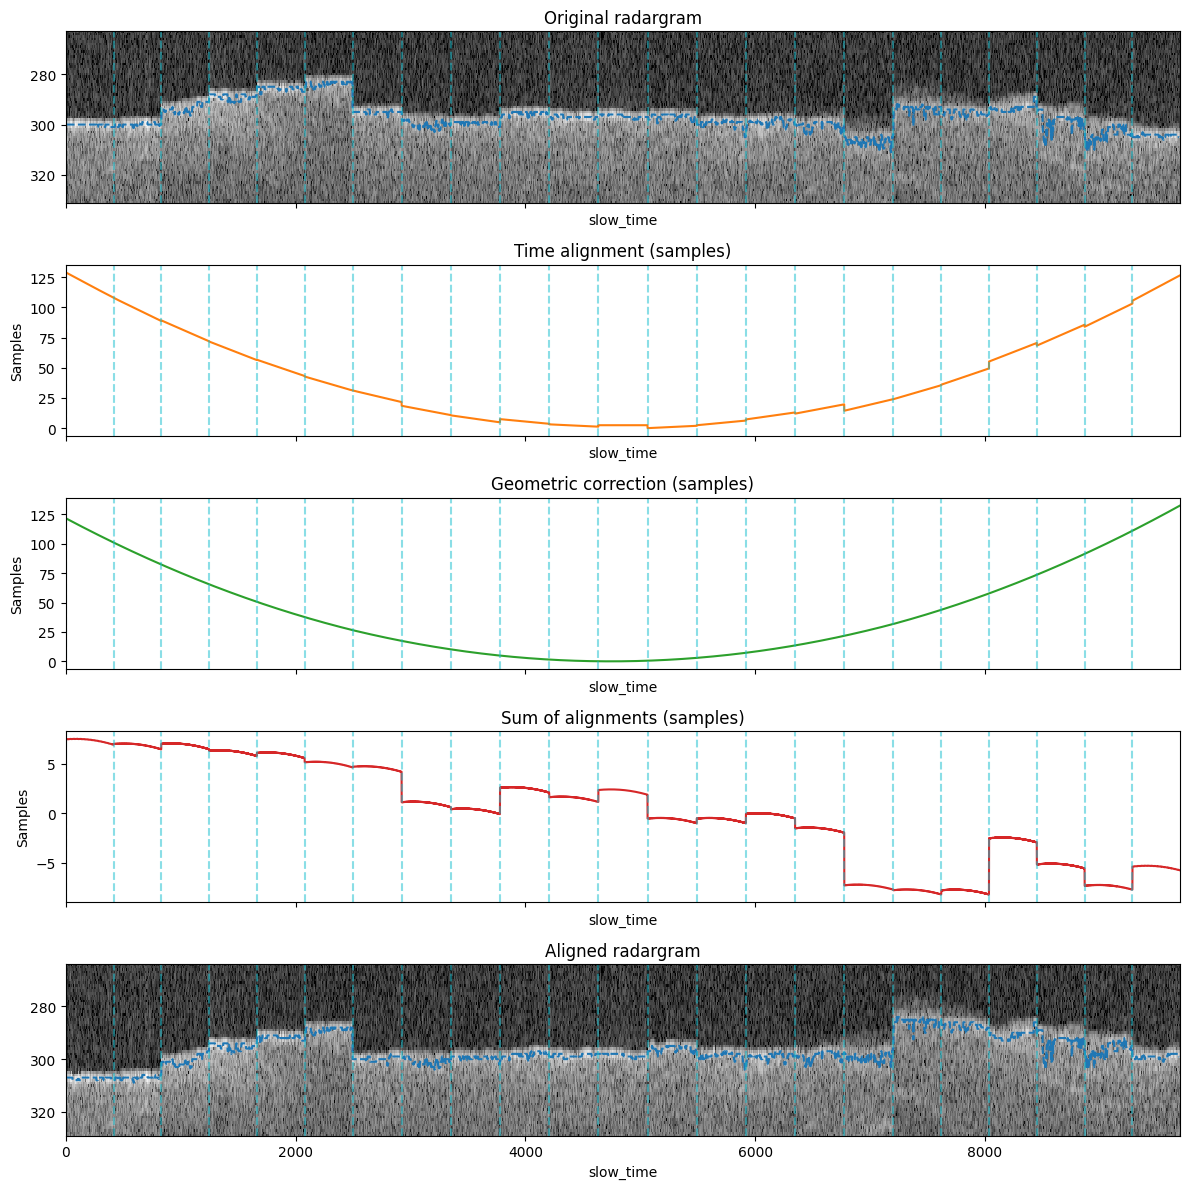

In [9]:

# Plot
fig, (ax_radargram_orig, ax_time_alignment, ax_geometric_alignment, ax_sum_alignment, ax_radargram_aligned) = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

x = np.arange(len(stacked_data))
vmin, vmax = np.max(data_db) - 60, np.max(data_db)
p = data_db.plot(ax=ax_radargram_orig, y='range_bin', cmap='gray', add_colorbar=False, vmin=vmin, vmax=vmax)
ax_radargram_orig.invert_yaxis()
# Pick maximum from each slow_time bin and plot
max_values = data_db.argmax(dim='range_bin').rolling(slow_time=20, center=True).median()
max_values.plot(ax=ax_radargram_orig, color='tab:blue', alpha=1, linestyle='--', label='Surface pick')
ax_radargram_orig.set_ylim(max_values.max() + 20, max_values.min() - 20)
ax_radargram_orig.set_title("Original radargram")

time_alignment_samples.plot(ax=ax_time_alignment, color='tab:orange', label='Time alignment (samples)')
ax_time_alignment.set_title("Time alignment (samples)")
ax_time_alignment.set_ylabel("Samples")
geometric_correction_samples.plot(ax=ax_geometric_alignment, color='tab:green', label='Geometric correction (samples)')
ax_geometric_alignment.set_title("Geometric correction (samples)")
ax_geometric_alignment.set_ylabel("Samples")
sample_alignment_sum.plot(ax=ax_sum_alignment, color='tab:red', label='Sum of alignments (samples)')
ax_sum_alignment.set_title("Sum of alignments (samples)")
ax_sum_alignment.set_ylabel("Samples")

p2 = data_db_aligned.plot(ax=ax_radargram_aligned, y='range_bin', cmap='gray', add_colorbar=False, vmin=vmin, vmax=vmax)
ax_radargram_aligned.invert_yaxis()
# Pick maximum from each slow_time bin and plot
max_values = data_db_aligned.argmax(dim='range_bin').rolling(slow_time=20, center=True).median()
max_values.plot(ax=ax_radargram_aligned, color='tab:blue', alpha=1, linestyle='--', label='Surface pick')
ax_radargram_aligned.set_ylim(max_values.max() + 20, max_values.min() - 20)
ax_radargram_aligned.set_title("Aligned radargram")

# Overlay vertical lines to indicate dwell boundaries
for idx in stacked_dwell_start_idxs:
    for ax in fig.axes:
        ax.axvline(x=idx, color='tab:cyan', linestyle='--', alpha=0.5)

fig.tight_layout()

In [10]:
channel['science']

<xarray.DataTree 'science'>
Group: /HF/science
    Dimensions:    (slow_time: 9698, fast_time: 964)
    Coordinates:
      * slow_time  (slow_time) int64 78kB 0 1 2 3 4 5 ... 9693 9694 9695 9696 9697
      * fast_time  (fast_time) float64 8kB 0.0 0.8333 1.667 ... 800.8 801.7 802.5
    Data variables:
        complex    (slow_time, fast_time) complex64 75MB (470.27078+1158.5983j) ....
    Attributes:
        channel_name:     HF
        frequency:        9 MHz
        sample_rate_hz:   1200000.0
        description:      HF radar data
        n_slow_time:      9698
        n_fast_time:      964
        fast_time_units:  microseconds
        source_file:      REA000MGA_2025060T1736_09TCOMBSCI_PPD020.BIN

Engineering slow time dimension size: 9698
Mission engineering slow time dimension size: 9698
Science slow time dimension size: 9698


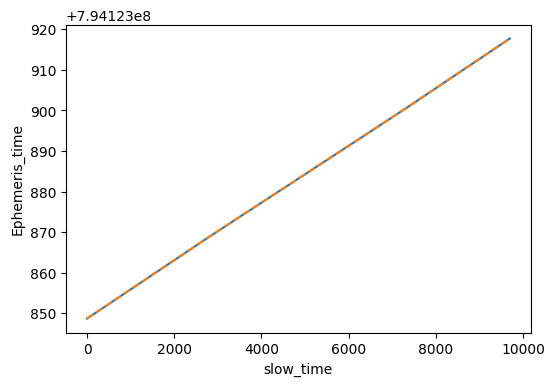

In [11]:
# Verify that slow_time dimensions match

print(f"Engineering slow time dimension size: {channel['engineering'].slow_time.size}")
print(f"Mission engineering slow time dimension size: {channel['med'].slow_time.size}")
print(f"Science slow time dimension size: {channel['science'].slow_time.size}")

fig, ax = plt.subplots(figsize=(6, 4))
channel['engineering']['Ephemeris_time'].plot(ax=ax)
channel['med']['Ephemeris_time'].plot(ax=ax, linestyle='--')